# 01 — Exploratory Data Analysis
**Banking Churn Prediction**

Objetivo: entender la distribución del dataset, la variable target y las relaciones entre features y churn antes de diseñar el pipeline de features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

DATA_PATH = '../data/raw/Customer-Churn-Records.csv'
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (10000, 18)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## 1. Estructura y calidad de datos

In [2]:
print('=== TIPOS Y NULOS ===')
info = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.count(),
    'null': df.isnull().sum(),
    'null_%': (df.isnull().mean() * 100).round(2),
    'unique': df.nunique()
})
print(info.to_string())

=== TIPOS Y NULOS ===
                      dtype  non_null  null  null_%  unique
RowNumber             int64     10000     0     0.0   10000
CustomerId            int64     10000     0     0.0   10000
Surname                 str     10000     0     0.0    2932
CreditScore           int64     10000     0     0.0     460
Geography               str     10000     0     0.0       3
Gender                  str     10000     0     0.0       2
Age                   int64     10000     0     0.0      70
Tenure                int64     10000     0     0.0      11
Balance             float64     10000     0     0.0    6382
NumOfProducts         int64     10000     0     0.0       4
HasCrCard             int64     10000     0     0.0       2
IsActiveMember        int64     10000     0     0.0       2
EstimatedSalary     float64     10000     0     0.0    9999
Exited                int64     10000     0     0.0       2
Complain              int64     10000     0     0.0       2
Satisfaction Score

In [3]:
# Columnas a descartar (identificadores, no features)
DROP_COLS = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=DROP_COLS)
print(f'Features disponibles ({len(df.columns)-1}): {[c for c in df.columns if c != "Exited"]}')
print(f'Target: Exited')

Features disponibles (14): ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned']
Target: Exited


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0
HasCrCard,10000.0,NaN,NaN,NaN,0.7055,0.45584,0.0,0.0,1.0,1.0,1.0
IsActiveMember,10000.0,NaN,NaN,NaN,0.5151,0.499797,0.0,0.0,1.0,1.0,1.0
EstimatedSalary,10000.0,NaN,NaN,NaN,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48


## 2. Variable Target — Distribución de Churn

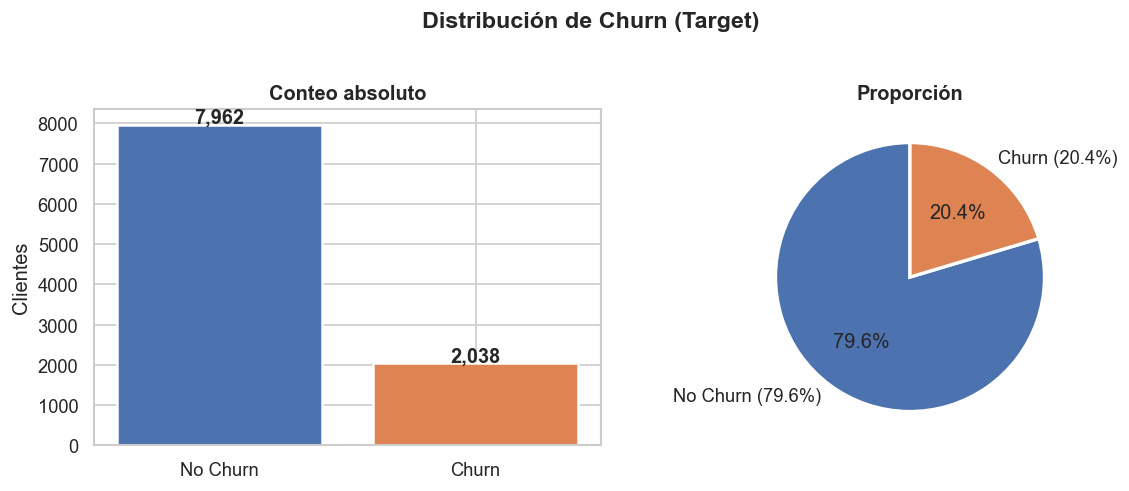


Clase mayoritaria (No Churn): 7,962 (79.6%)
Clase minoritaria (Churn):    2,038 (20.4%)
Ratio de desbalance: 3.9:1


In [5]:
churn_counts = df['Exited'].value_counts()
churn_pct = df['Exited'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['No Churn', 'Churn'], churn_counts, color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Conteo absoluto', fontweight='bold')
axes[0].set_ylabel('Clientes')
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(churn_counts, labels=['No Churn (79.6%)', 'Churn (20.4%)'],
            colors=['#4C72B0', '#DD8452'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción', fontweight='bold')

plt.suptitle('Distribución de Churn (Target)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nClase mayoritaria (No Churn): {churn_counts[0]:,} ({churn_pct[0]:.1f}%)')
print(f'Clase minoritaria (Churn):    {churn_counts[1]:,} ({churn_pct[1]:.1f}%)')
print(f'Ratio de desbalance: {churn_counts[0]/churn_counts[1]:.1f}:1')

## 3. Variables Numéricas — Distribuciones

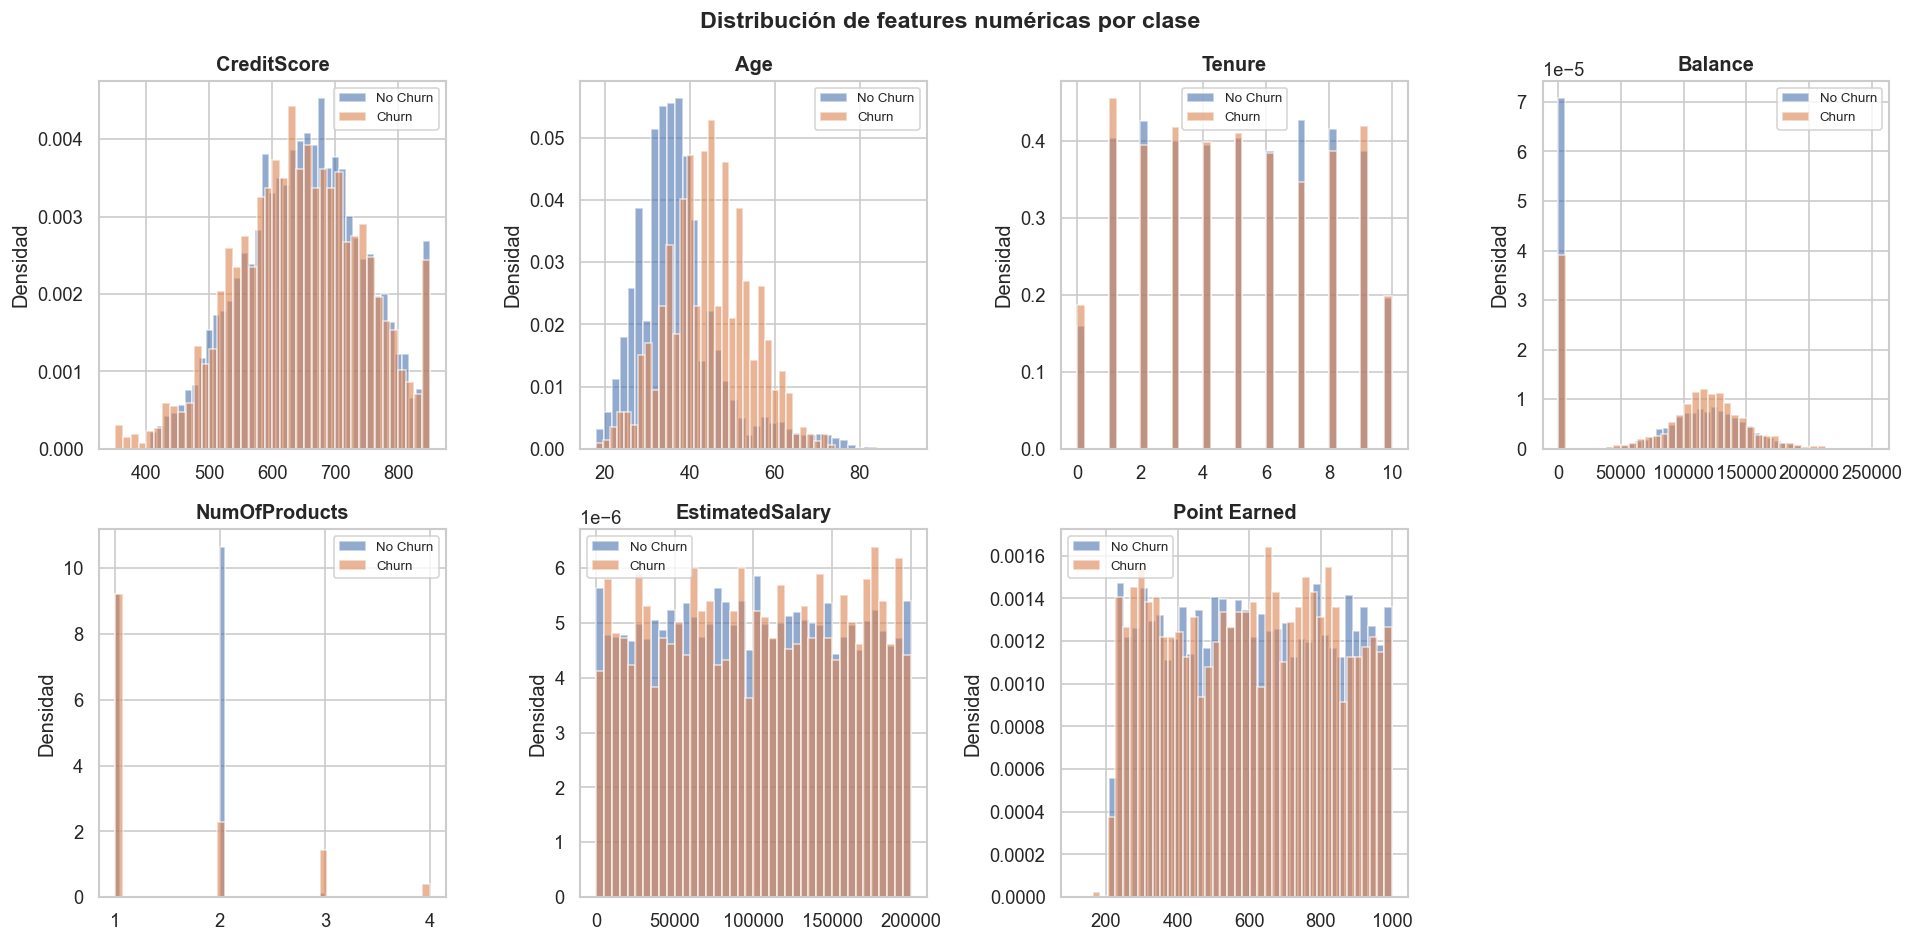

In [6]:
NUM_COLS = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Point Earned']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    churned = df[df['Exited'] == 1][col]
    not_churned = df[df['Exited'] == 0][col]
    ax.hist(not_churned, bins=40, alpha=0.6, color='#4C72B0', label='No Churn', density=True)
    ax.hist(churned, bins=40, alpha=0.6, color='#DD8452', label='Churn', density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylabel('Densidad')

axes[-1].axis('off')
plt.suptitle('Distribución de features numéricas por clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Variables Categóricas — Tasa de Churn

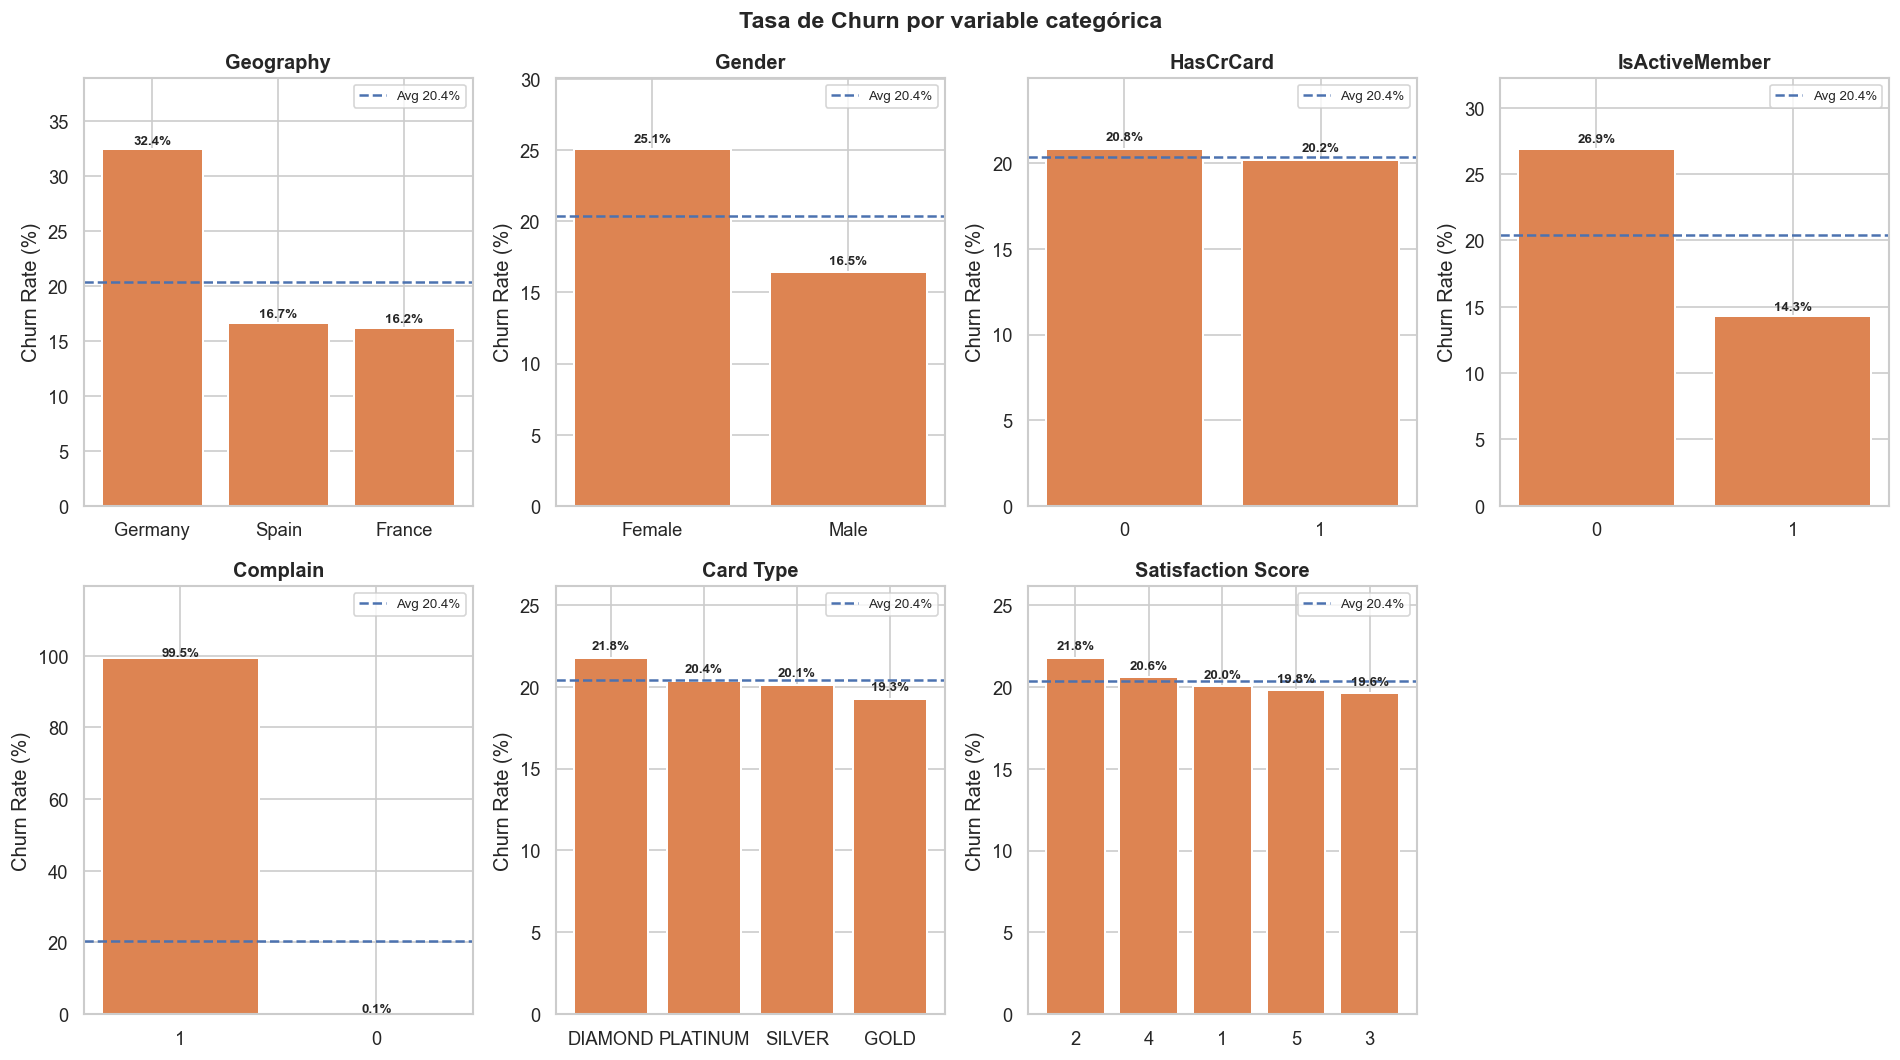

In [7]:
CAT_COLS = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'Complain', 'Card Type', 'Satisfaction Score']

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    churn_rate = df.groupby(col)['Exited'].mean().sort_values(ascending=False) * 100
    counts = df.groupby(col)['Exited'].count()
    ax = axes[i]
    bars = ax.bar(churn_rate.index.astype(str), churn_rate.values,
                  color='#DD8452', edgecolor='white', linewidth=1.2)
    ax.axhline(df['Exited'].mean() * 100, color='#4C72B0', linestyle='--', linewidth=1.5, label='Avg 20.4%')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.legend(fontsize=8)
    for bar, (cat, rate) in zip(bars, churn_rate.items()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{rate:.1f}%', ha='center', fontsize=8, fontweight='bold')
    ax.set_ylim(0, churn_rate.max() * 1.2)

axes[-1].axis('off')
plt.suptitle('Tasa de Churn por variable categórica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Análisis de Age — Feature más discriminante

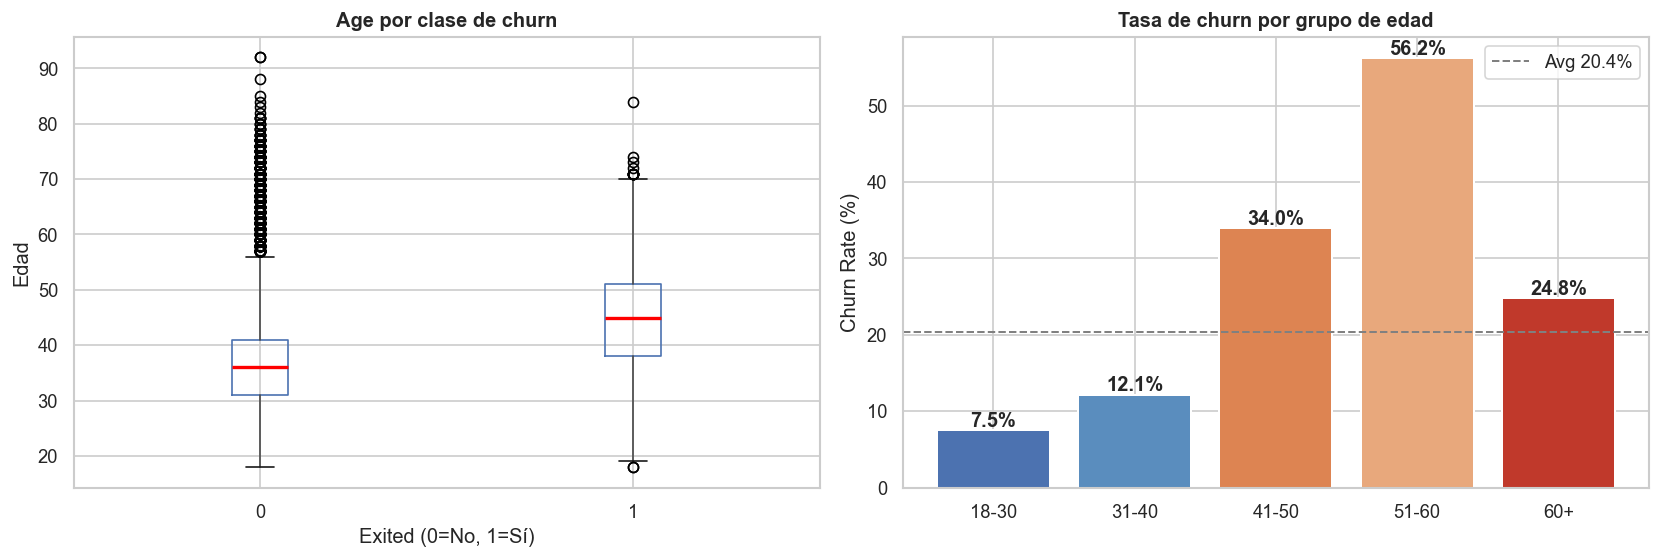

Insight: clientes 51-60 años tienen la mayor tasa de churn. El grupo 31-40 es el más fiel.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot Age por churn
df.boxplot(column='Age', by='Exited', ax=axes[0],
           boxprops=dict(color='#4C72B0'), medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Age por clase de churn', fontweight='bold')
axes[0].set_xlabel('Exited (0=No, 1=Sí)')
axes[0].set_ylabel('Edad')
plt.sca(axes[0])
plt.title('Age por clase de churn', fontweight='bold')

# Churn rate por grupo de edad
df['age_bin'] = pd.cut(df['Age'], bins=[18, 30, 40, 50, 60, 100],
                        labels=['18-30', '31-40', '41-50', '51-60', '60+'])
age_churn = df.groupby('age_bin', observed=True)['Exited'].mean() * 100
axes[1].bar(age_churn.index.astype(str), age_churn.values,
            color=['#4C72B0', '#5A8DBE', '#DD8452', '#E8A87C', '#C0392B'],
            edgecolor='white', linewidth=1.2)
axes[1].axhline(20.4, color='gray', linestyle='--', linewidth=1.2, label='Avg 20.4%')
axes[1].set_title('Tasa de churn por grupo de edad', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend()
for i, v in enumerate(age_churn):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('')
plt.tight_layout()
plt.show()

df = df.drop(columns=['age_bin'])
print('Insight: clientes 51-60 años tienen la mayor tasa de churn. El grupo 31-40 es el más fiel.')

## 6. Balance — Cero-balance como señal de churn

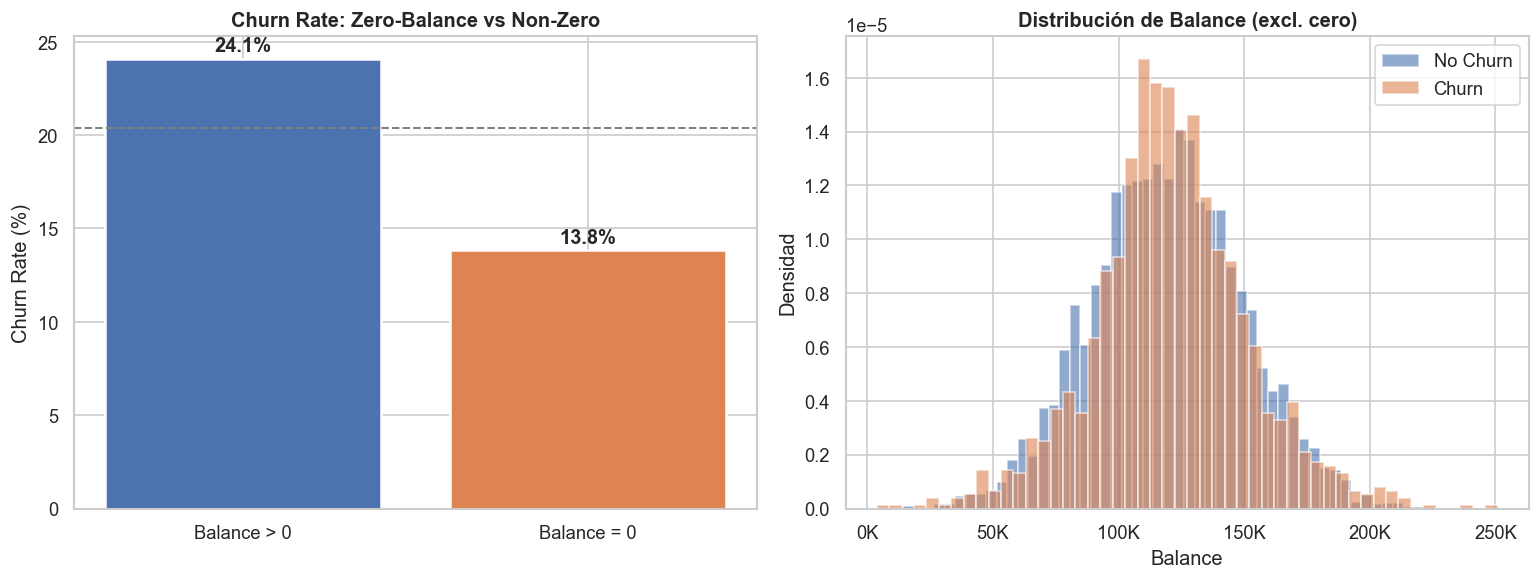

Clientes con balance = 0: 3617 (36.2%)
Churn rate balance=0: 13.8% | balance>0: 24.1%


In [9]:
df['zero_balance'] = (df['Balance'] == 0).astype(int)
zero_bal_churn = df.groupby('zero_balance')['Exited'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = ['Balance > 0', 'Balance = 0']
axes[0].bar(labels, zero_bal_churn.values, color=['#4C72B0', '#DD8452'],
            edgecolor='white', linewidth=1.5)
axes[0].axhline(20.4, color='gray', linestyle='--', linewidth=1.2)
axes[0].set_title('Churn Rate: Zero-Balance vs Non-Zero', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(zero_bal_churn):
    axes[0].text(i, v + 0.4, f'{v:.1f}%', ha='center', fontweight='bold')

# Distribución de balance para churners vs no churners (solo balance > 0)
non_zero = df[df['Balance'] > 0]
axes[1].hist(non_zero[non_zero['Exited'] == 0]['Balance'], bins=50,
             alpha=0.6, color='#4C72B0', label='No Churn', density=True)
axes[1].hist(non_zero[non_zero['Exited'] == 1]['Balance'], bins=50,
             alpha=0.6, color='#DD8452', label='Churn', density=True)
axes[1].set_title('Distribución de Balance (excl. cero)', fontweight='bold')
axes[1].set_xlabel('Balance')
axes[1].set_ylabel('Densidad')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

df = df.drop(columns=['zero_balance'])
n_zero = (df['Balance'] == 0).sum()
print(f'Clientes con balance = 0: {n_zero} ({n_zero/len(df)*100:.1f}%)')
print(f'Churn rate balance=0: {zero_bal_churn[1]:.1f}% | balance>0: {zero_bal_churn[0]:.1f}%')

## 7. NumOfProducts — Relación no lineal con churn

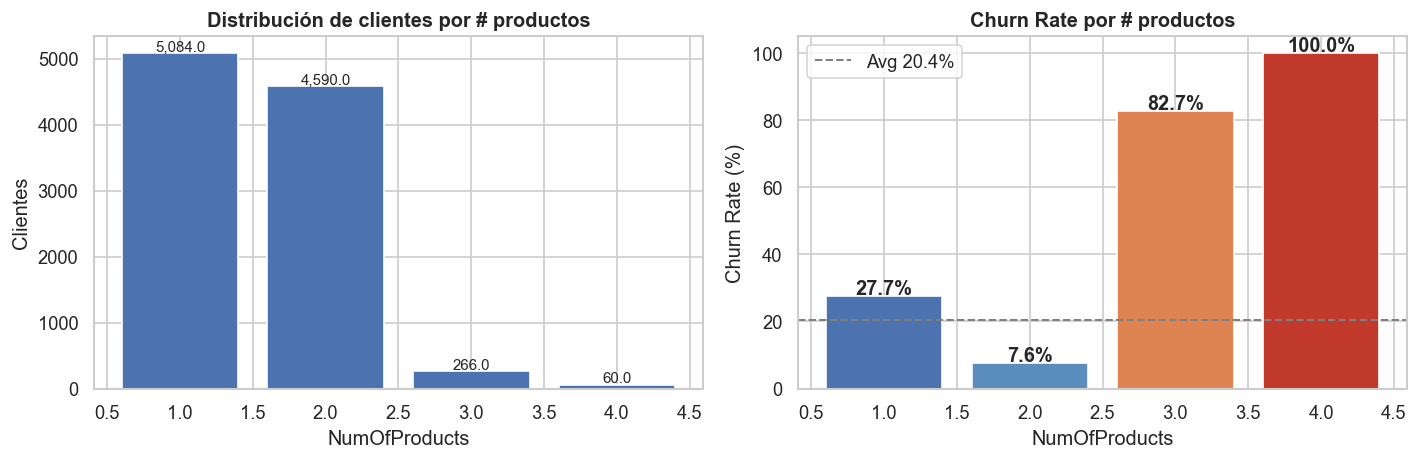

 NumOfProducts  count  churn_rate  churn_rate_pct
             1   5084    0.277144       27.714398
             2   4590    0.076035        7.603486
             3    266    0.827068       82.706767
             4     60    1.000000      100.000000

Insight: clientes con 3-4 productos tienen churn extremadamente alto (82-100%).
Clientes con 2 productos son los más fieles (<8%).


In [10]:
prod_stats = df.groupby('NumOfProducts').agg(
    count=('Exited', 'count'),
    churn_rate=('Exited', 'mean')
).reset_index()
prod_stats['churn_rate_pct'] = prod_stats['churn_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(prod_stats['NumOfProducts'], prod_stats['count'],
            color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribución de clientes por # productos', fontweight='bold')
axes[0].set_xlabel('NumOfProducts')
axes[0].set_ylabel('Clientes')
for _, row in prod_stats.iterrows():
    axes[0].text(row['NumOfProducts'], row['count'] + 30,
                 f"{row['count']:,}", ha='center', fontsize=9)

colors = ['#4C72B0', '#5A8DBE', '#DD8452', '#C0392B']
axes[1].bar(prod_stats['NumOfProducts'], prod_stats['churn_rate_pct'],
            color=colors[:len(prod_stats)], edgecolor='white')
axes[1].axhline(20.4, color='gray', linestyle='--', linewidth=1.2, label='Avg 20.4%')
axes[1].set_title('Churn Rate por # productos', fontweight='bold')
axes[1].set_xlabel('NumOfProducts')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend()
for _, row in prod_stats.iterrows():
    axes[1].text(row['NumOfProducts'], row['churn_rate_pct'] + 0.5,
                 f"{row['churn_rate_pct']:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print(prod_stats.to_string(index=False))
print('\nInsight: clientes con 3-4 productos tienen churn extremadamente alto (82-100%).')
print('Clientes con 2 productos son los más fieles (<8%).')

## 8. IsActiveMember y Complain — Features binarias clave

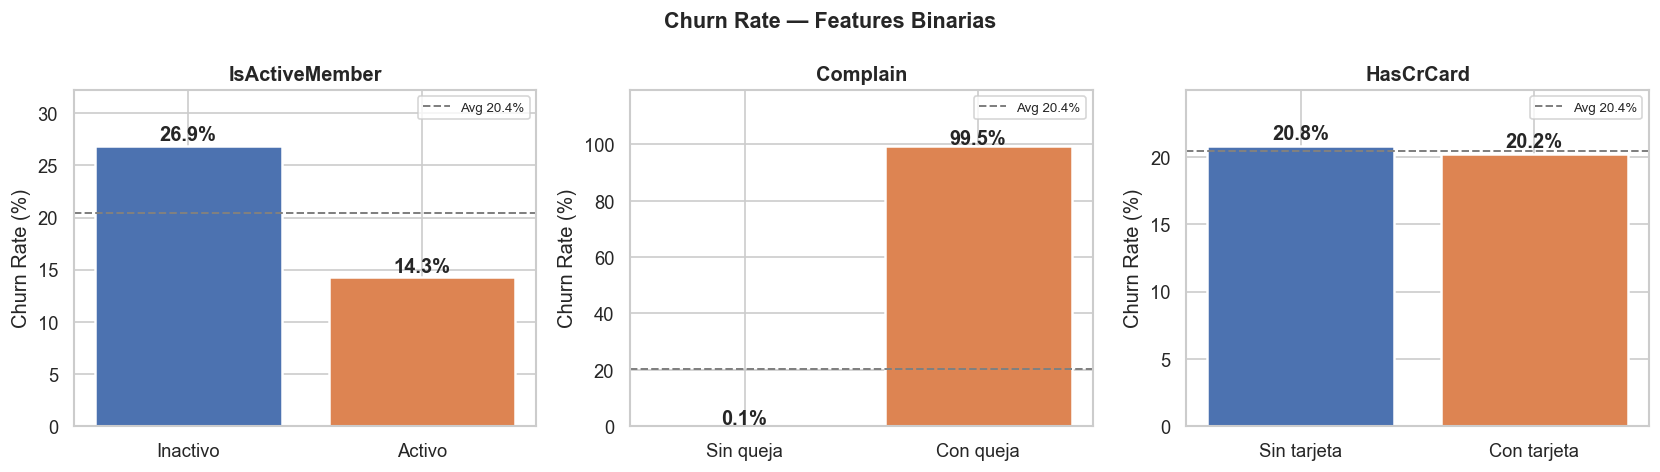

Complain=1 → Churn Rate: 99.5% (señal muy fuerte)
IsActiveMember=0 → Churn Rate: 26.9%


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, labels in zip(
    axes,
    ['IsActiveMember', 'Complain', 'HasCrCard'],
    [['Inactivo', 'Activo'], ['Sin queja', 'Con queja'], ['Sin tarjeta', 'Con tarjeta']]
):
    rates = df.groupby(col)['Exited'].mean() * 100
    bars = ax.bar(labels, rates.values, color=['#4C72B0', '#DD8452'],
                  edgecolor='white', linewidth=1.5)
    ax.axhline(20.4, color='gray', linestyle='--', linewidth=1.2, label='Avg 20.4%')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold')
    ax.set_ylim(0, max(rates.values) * 1.2)

plt.suptitle('Churn Rate — Features Binarias', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

complain_churn = df[df['Complain'] == 1]['Exited'].mean() * 100
active_churn = df[df['IsActiveMember'] == 0]['Exited'].mean() * 100
print(f'Complain=1 → Churn Rate: {complain_churn:.1f}% (señal muy fuerte)')
print(f'IsActiveMember=0 → Churn Rate: {active_churn:.1f}%')

## 9. Satisfaction Score vs Churn

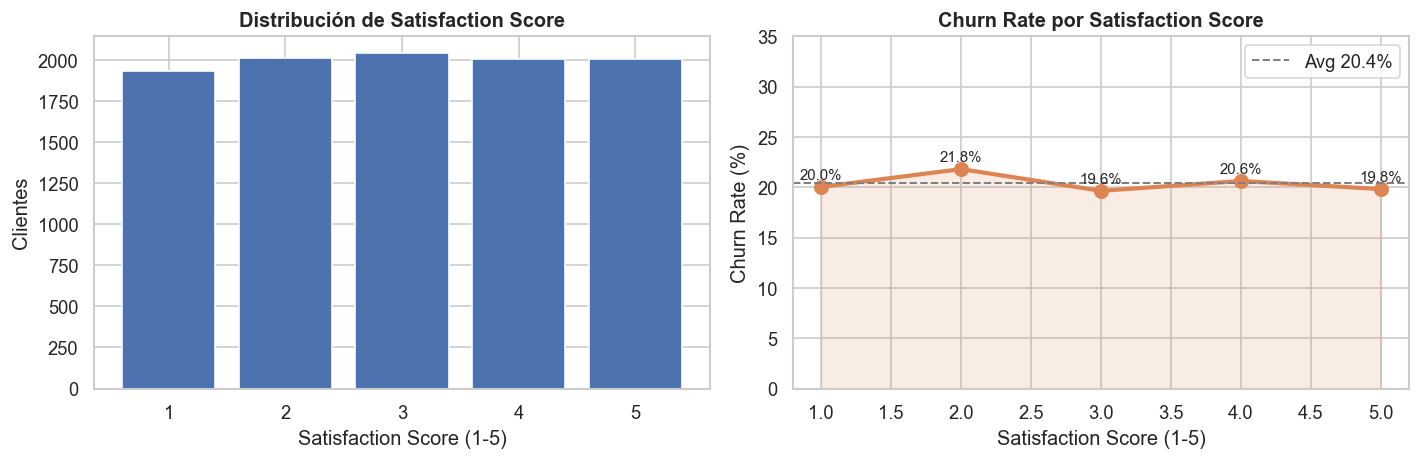

 Satisfaction Score  count  churn_rate  churn_rate_pct
                  1   1932    0.200311       20.031056
                  2   2014    0.217974       21.797418
                  3   2042    0.196376       19.637610
                  4   2008    0.206175       20.617530
                  5   2004    0.198104       19.810379

Insight: Satisfaction Score no muestra patrón claro lineal con churn → puede capturarse como feature categórica.


In [12]:
sat_stats = df.groupby('Satisfaction Score').agg(
    count=('Exited', 'count'),
    churn_rate=('Exited', 'mean')
).reset_index()
sat_stats['churn_rate_pct'] = sat_stats['churn_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(sat_stats['Satisfaction Score'], sat_stats['count'],
            color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribución de Satisfaction Score', fontweight='bold')
axes[0].set_xlabel('Satisfaction Score (1-5)')
axes[0].set_ylabel('Clientes')

axes[1].plot(sat_stats['Satisfaction Score'], sat_stats['churn_rate_pct'],
             marker='o', color='#DD8452', linewidth=2.5, markersize=8)
axes[1].fill_between(sat_stats['Satisfaction Score'], sat_stats['churn_rate_pct'],
                     alpha=0.15, color='#DD8452')
axes[1].axhline(20.4, color='gray', linestyle='--', linewidth=1.2, label='Avg 20.4%')
axes[1].set_title('Churn Rate por Satisfaction Score', fontweight='bold')
axes[1].set_xlabel('Satisfaction Score (1-5)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend()
axes[1].set_ylim(0, 35)
for _, row in sat_stats.iterrows():
    axes[1].text(row['Satisfaction Score'], row['churn_rate_pct'] + 0.8,
                 f"{row['churn_rate_pct']:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()
print(sat_stats.to_string(index=False))
print('\nInsight: Satisfaction Score no muestra patrón claro lineal con churn → puede capturarse como feature categórica.')

## 10. Matriz de Correlación

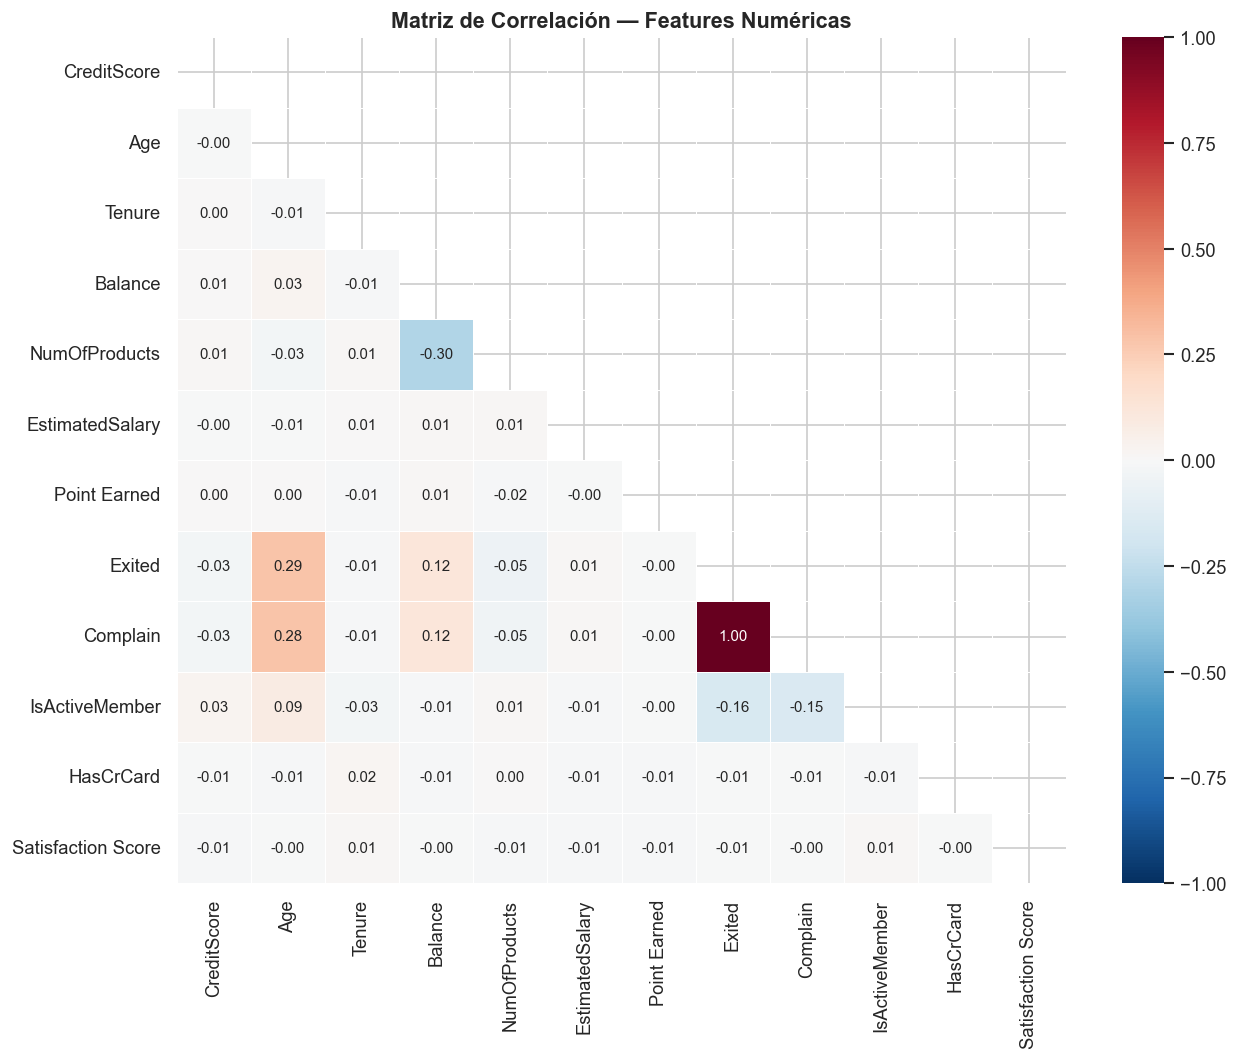

=== CORRELACIONES CON Exited (descendente) ===
Complain              0.995693
Age                   0.285296
IsActiveMember       -0.156356
Balance               0.118577
NumOfProducts        -0.047611
CreditScore          -0.026771
Tenure               -0.013656
EstimatedSalary       0.012490
HasCrCard            -0.006976
Satisfaction Score   -0.005849
Point Earned         -0.004628


In [13]:
num_df = df[NUM_COLS + ['Exited', 'Complain', 'IsActiveMember', 'HasCrCard', 'Satisfaction Score']]
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 9})
ax.set_title('Matriz de Correlación — Features Numéricas', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('=== CORRELACIONES CON Exited (descendente) ===')
print(corr['Exited'].drop('Exited').sort_values(key=abs, ascending=False).to_string())

## 11. Análisis Multivariado — Interacciones clave

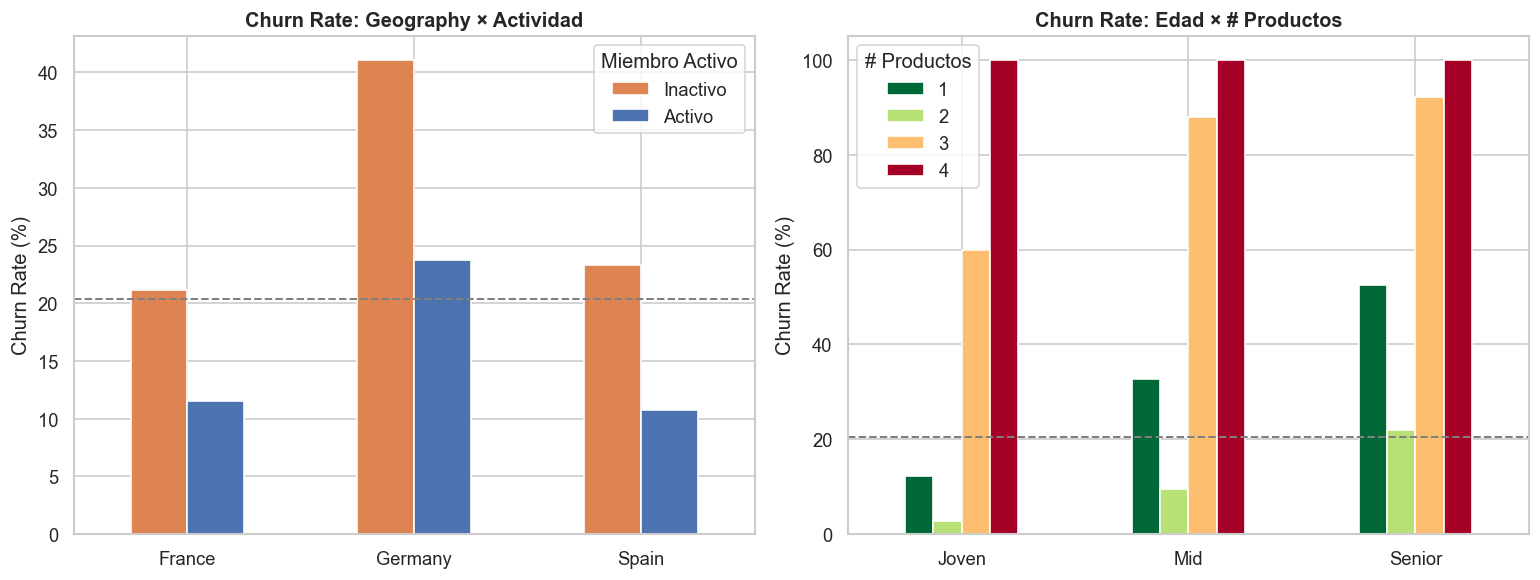

In [14]:
# Geography × IsActiveMember × Churn
pivot = df.pivot_table(values='Exited', index='Geography',
                        columns='IsActiveMember', aggfunc='mean') * 100
pivot.columns = ['Inactivo', 'Activo']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pivot.plot(kind='bar', ax=axes[0], color=['#DD8452', '#4C72B0'],
           edgecolor='white', linewidth=1)
axes[0].axhline(20.4, color='gray', linestyle='--', linewidth=1.2)
axes[0].set_title('Churn Rate: Geography × Actividad', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('')
axes[0].legend(title='Miembro Activo')
axes[0].tick_params(axis='x', rotation=0)

# Age × NumOfProducts
df['age_group'] = pd.cut(df['Age'], bins=[18, 35, 50, 100], labels=['Joven', 'Mid', 'Senior'])
pivot2 = df.pivot_table(values='Exited', index='age_group',
                         columns='NumOfProducts', aggfunc='mean', observed=True) * 100
pivot2.plot(kind='bar', ax=axes[1], colormap='RdYlGn_r',
            edgecolor='white', linewidth=1)
axes[1].axhline(20.4, color='gray', linestyle='--', linewidth=1.2)
axes[1].set_title('Churn Rate: Edad × # Productos', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('')
axes[1].legend(title='# Productos')
axes[1].tick_params(axis='x', rotation=0)

df = df.drop(columns=['age_group'])
plt.tight_layout()
plt.show()

## 12. Resumen de Insights — Decisiones para Feature Engineering

In [15]:
insights = {
    'Feature': [
        'Complain', 'Age', 'NumOfProducts', 'IsActiveMember',
        'Geography', 'Balance', 'Satisfaction Score', 'CreditScore',
        'Gender', 'HasCrCard', 'Card Type', 'Tenure', 'EstimatedSalary', 'Point Earned'
    ],
    'Importancia estimada': [
        'MUY ALTA', 'MUY ALTA', 'ALTA', 'ALTA',
        'ALTA', 'ALTA', 'MEDIA', 'MEDIA',
        'MEDIA', 'BAJA', 'BAJA-MEDIA', 'BAJA', 'BAJA', 'BAJA'
    ],
    'Insight clave': [
        'Clientes con queja churnan ~100%',
        'Senior (51-60) churn 3× más que jóvenes',
        '3-4 productos → churn 82-100%; 2 productos → 7.6%',
        'Inactivos churnan 2× más que activos',
        'Alemania churn 32% vs Francia/España ~16%',
        'Balance=0: churn 14%; Balance>0: media/alta',
        'Score 1-5 sin patrón claro lineal',
        'Relación débil, distribuciones solapadas',
        'Mujeres churn 25% vs hombres 16%',
        'Sin diferencia significativa',
        'Pequeñas diferencias entre tipos',
        'Sin diferencia significativa',
        'Sin diferencia significativa',
        'Baja correlación con Exited'
    ],
    'Feature Engineering': [
        'Usar directamente (binaria)',
        'Crear age_segment (Joven/Mid/Senior/Elder)',
        'Crear flag: products_3plus',
        'Usar directamente + interacción con Geography',
        'OneHot; crear flag: is_german',
        'Crear flag: zero_balance; balance_per_product',
        'Tratar como ordinal o categórica',
        'Usar directamente (continua)',
        'Label encode (Female=1)',
        'Usar directamente',
        'Label encode o OneHot',
        'Usar directamente',
        'Usar directamente',
        'Usar directamente o transformación log'
    ]
}

summary = pd.DataFrame(insights)
print('=== RESUMEN DE INSIGHTS EDA ===')
print(summary.to_string(index=False))

=== RESUMEN DE INSIGHTS EDA ===
           Feature Importancia estimada                                     Insight clave                           Feature Engineering
          Complain             MUY ALTA                  Clientes con queja churnan ~100%                   Usar directamente (binaria)
               Age             MUY ALTA           Senior (51-60) churn 3× más que jóvenes    Crear age_segment (Joven/Mid/Senior/Elder)
     NumOfProducts                 ALTA 3-4 productos → churn 82-100%; 2 productos → 7.6%                    Crear flag: products_3plus
    IsActiveMember                 ALTA              Inactivos churnan 2× más que activos Usar directamente + interacción con Geography
         Geography                 ALTA         Alemania churn 32% vs Francia/España ~16%                 OneHot; crear flag: is_german
           Balance                 ALTA       Balance=0: churn 14%; Balance>0: media/alta Crear flag: zero_balance; balance_per_product
Satisfaction Sco

In [16]:
print('=== DECISIONES PARA FEATURE ENGINEERING (notebook 02) ===')
print()
print('FEATURES A CREAR:')
print('  1. age_segment         → Joven(<=35) / Mid(36-50) / Senior(51-60) / Elder(60+)')
print('  2. balance_per_product → Balance / NumOfProducts')
print('  3. zero_balance        → 1 si Balance == 0')
print('  4. products_3plus      → 1 si NumOfProducts >= 3')
print('  5. is_german           → 1 si Geography == Germany')
print('  6. engagement_score    → IsActiveMember * (1 - zero_balance) * log1p(Tenure)')
print('  7. risk_profile        → combinación Balance + actividad + productos')
print()
print('ENCODING:')
print('  - Geography → OneHotEncoder (drop=first)')
print('  - Gender    → LabelEncoder (Female=1)')
print('  - Card Type → OrdinalEncoder (SILVER < GOLD < PLATINUM < DIAMOND)')
print()
print('TRATAMIENTO DE DESBALANCE: SMOTE en training set')
print('SCALING: StandardScaler para features numéricas continuas')

=== DECISIONES PARA FEATURE ENGINEERING (notebook 02) ===

FEATURES A CREAR:
  1. age_segment         → Joven(<=35) / Mid(36-50) / Senior(51-60) / Elder(60+)
  2. balance_per_product → Balance / NumOfProducts
  3. zero_balance        → 1 si Balance == 0
  4. products_3plus      → 1 si NumOfProducts >= 3
  5. is_german           → 1 si Geography == Germany
  6. engagement_score    → IsActiveMember * (1 - zero_balance) * log1p(Tenure)
  7. risk_profile        → combinación Balance + actividad + productos

ENCODING:
  - Geography → OneHotEncoder (drop=first)
  - Gender    → LabelEncoder (Female=1)
  - Card Type → OrdinalEncoder (SILVER < GOLD < PLATINUM < DIAMOND)

TRATAMIENTO DE DESBALANCE: SMOTE en training set
SCALING: StandardScaler para features numéricas continuas
